In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch02_checkpoints"

In [3]:
json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

if len(json_files) > 2:
    print(f"--> Loaded: files={len(json_files)}, start={json_files[0].name}, end={json_files[-1].name}")

epoches, steps, = [], []
train_losses, val_losses = [], []
created_at = []

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    tags = f.name.replace("checkpoint_", "").replace(".json", "").split("-", 1)
    epoches.append(int(tags[1])) 
    steps.append(int(tags[1]))
    train_losses.append(data['train_loss'])
    val_losses.append(data['eval_loss'])
    created_at.append(data['created_at'])

--> Loaded: files=338, start=checkpoint_001-194000.json, end=checkpoint_001-131000.json


In [4]:
df = pd.DataFrame({
    "epoch": epoches,
    "step": steps,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "created_at": created_at,
})

df = df.sort_values(by='step', ascending=True)

#print(df)
df

,epoch,step,train_loss,val_loss,created_at
134,31000,31000,2.035359,2.460172,2025-09-01T13:36:32+08:00
118,32000,32000,2.002379,2.467355,2025-09-01T13:39:12+08:00
275,33000,33000,1.957576,2.400275,2025-09-01T13:41:52+08:00
60,34000,34000,1.929860,2.383639,2025-09-01T13:44:32+08:00
227,35000,35000,1.899599,2.371994,2025-09-01T13:47:12+08:00
...,...,...,...,...,...
162,374000,374000,1.148491,2.491470,2025-09-03T11:57:08+08:00
84,375000,375000,1.146735,2.502277,2025-09-03T11:59:48+08:00
204,376000,376000,1.139758,2.512739,2025-09-03T12:02:28+08:00
310,377000,377000,1.145703,2.526453,2025-09-03T12:05:07+08:00


In [8]:
df.tail(20)

,epoch,step,train_loss,val_loss,created_at
250,359000,359000,1.152017,2.512117,2025-09-03T11:17:13+08:00
319,360000,360000,1.160412,2.461131,2025-09-03T11:19:53+08:00
213,361000,361000,1.150329,2.499065,2025-09-03T11:22:33+08:00
221,362000,362000,1.150204,2.542286,2025-09-03T11:25:12+08:00
153,363000,363000,1.146725,2.471528,2025-09-03T11:27:52+08:00
237,364000,364000,1.144313,2.474577,2025-09-03T11:30:32+08:00
202,365000,365000,1.141938,2.507933,2025-09-03T11:33:11+08:00
286,366000,366000,1.149544,2.473753,2025-09-03T11:35:51+08:00
302,367000,367000,1.149561,2.485855,2025-09-03T11:38:31+08:00
39,368000,368000,1.152114,2.518379,2025-09-03T11:41:11+08:00


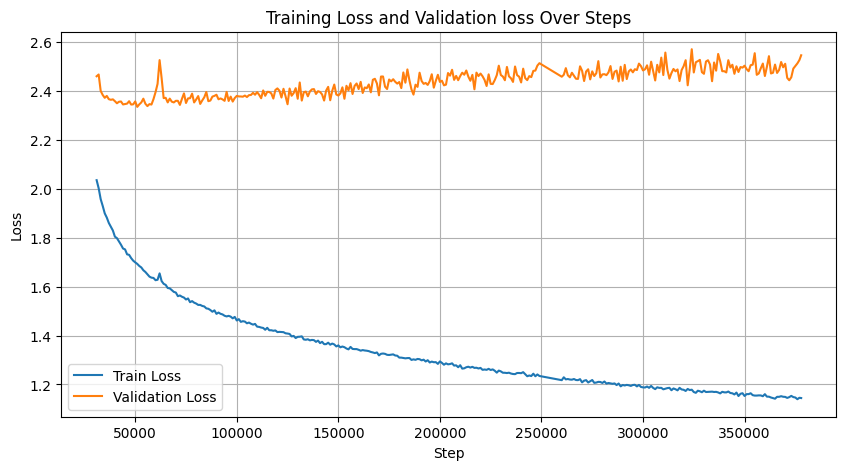

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['train_loss'], label="Train Loss")
plt.plot(df['step'], df['val_loss'], label="Validation Loss") # marker='o'
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss and Validation loss Over Steps")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")